# Colorectal Histology 3
Vou seguir o mesmo padrão do MNIST, mas com histologia colorretal. O colorectal_histology é um dataset de imagens de Classificação de texturas na histologia do câncer colorretal. Cada exemplo é uma imagem RGB de 150 x 150 x 3 de uma das 8 classes.  
No terceiro modelo, a acurácia do treino subiu até ~65%, na validação, a acurácia ficou em ~44%, o que mostra que o Dropout está ajudou, eu fiz algumas correções nos hiperparâmetros. Também usar o Augmentation para aumentar a quantidade de dados disponíveis funcionou.  
Nesta tentativa, vou voltar as imagens para o tamanho original, adicionar mais épocas no treinamento e aumentar o filtro da camada convolucional.  
<small>**OBS:** É necessário baixar tensorflow-datasets (`pip install tensorflow-datasets`).  
Site: <https://www.tensorflow.org/datasets/catalog/colorectal_histology></small>

## Importando as bibliotecas

In [1]:
!pip install tensorflow-datasets tensorflow

In [2]:
import tensorflow as tf
import keras
import matplotlib
import numpy as np

import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils as np_utils
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt

In [3]:
# O dataset não vem dividido, então vou pegar ele e depois fazer a divisão
dataset = tfds.load('colorectal_histology', split = 'train', as_supervised = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.A8K4F9_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.


In [4]:
# Ele tem o tamanho de 5.000 imagens pelo que eu vi no site do tensorflow
# Tambem, ele vem em uma tupla (imagem, label), vou extrair as imagens e labels em arrays separados
# depois usar o train_test_split para separar a divisão para treino e teste
imagens = np.array([
    # Manter as dimensoes da imagem em 128x128
    # Na aula, como ele usa de um diretório, ele usar o target_size do ImageDataGenerator
    # como estou usando o tfds, o equivalente ao target_size seria tf.image.resize
    tf.image.resize(img, (128, 128)).numpy()
    for img, label in dataset
])
labels = np.array([
    label.numpy()
    for img, label in dataset
])

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    # Divisao de 80/20, sendo 80% para treino e 20% para teste
    imagens, labels, test_size = 0.2, random_state = 42
)

In [6]:
# Diferente da aula, nao vou precisar usar o reshape
X_treino = X_treino.astype('float32')
X_teste = X_teste.astype('float32')

In [7]:
# Agora vou normalizar eles
X_treino /= 255
X_teste /= 255
X_treino.max(), X_treino.min()

(np.float32(1.0), np.float32(0.0))

In [8]:
# Vou transformar as saidas para categoricos, no codigo da aula ele usa 10, porque sao 10 classes, no meu caso sao 8 classes
y_treino = np_utils.to_categorical(y_treino , 8)
y_teste = np_utils.to_categorical(y_teste, 8)
y_treino, y_teste

(array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]]))

In [9]:
y_treino[2]

array([0., 1., 0., 0., 0., 0., 0., 0.])

In [10]:
X_treino.shape, X_teste.shape

((4000, 128, 128, 3), (1000, 128, 128, 3))

Text(0.5, 1.0, 'Classe [0. 1. 0. 0. 0. 0. 0. 0.]')

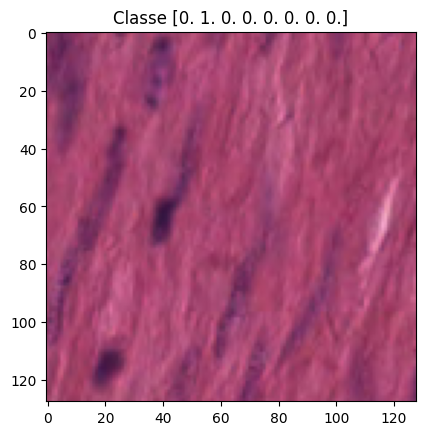

In [11]:
plt.imshow(X_treino[0])
plt.title('Classe ' + str(y_treino[0]))

In [12]:
gerador_treino = ImageDataGenerator(
    rotation_range=7,
    horizontal_flip=True,
    shear_range=0.2,
    height_shift_range=0.07,
    zoom_range=0.2
)

In [13]:
base_treino = gerador_treino.flow(X_treino, y_treino)

In [14]:
# Agora que tem os dados prontos, vou começar montar a rede neural,
rede_neural = Sequential()

# Aumentar para 128, ja que as imagens agora tem a dimensao 128x128
rede_neural.add(InputLayer(shape =(128, 128, 3)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

# Aumentar o filtro de uma das camadas convilucionais
rede_neural.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten())
# Adicionei Dropout depois do Flatten
rede_neural.add(Dropout(0.5))
# Alterei o dense de 128 para 64 para reduzir os parametros
rede_neural.add(Dense(units = 64, activation = 'relu'))
rede_neural.add(Dropout(0.5))
rede_neural.add(Dense(units = 8, activation = 'softmax'))

In [15]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,760 (14.14 MB)

 Trainable params: 3,706,568 (14.14 MB)

 Non-trainable params: 192 (768.00 B)

In [16]:
# Agora vou compilar a rede neural
# Vou usar a função de perda categorical_crossentropy, o otimizador adam e como métrica vou usar acurácia
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [17]:
# Finalmente, vou realizar o treino dela, vou aumentar as epocas para 25
rede_neural.fit(base_treino, epochs=25, validation_data=(X_teste, y_teste))

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.3345 - loss: 3.7025 - val_accuracy: 0.2870 - val_loss: 14.7217
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.3307 - loss: 1.7923 - val_accuracy: 0.3200 - val_loss: 17.3477
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.3503 - loss: 1.6927 - val_accuracy: 0.2790 - val_loss: 12.7346
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.4027 - loss: 1.5454 - val_accuracy: 0.4220 - val_loss: 2.4443
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.3997 - loss: 1.5029 - val_accuracy: 0.4070 - val_loss: 1.4112
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.4145 - loss: 1.4290 - val_accuracy: 0.4020 - val_loss: 1.2681
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.3993 - loss: 1.4384 - val_accuracy: 0.5070 - val_loss: 1.2709
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.4137 - loss

In [18]:
resultado = rede_neural.evaluate(X_teste, y_teste)
resultado

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3680 - loss: 1.4245


[1.4244709014892578, 0.36800000071525574]